In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
from ASM_utils import AdaptiveSmoothing
from matplotlib.colors import LinearSegmentedColormap
import warnings 
import os
import random
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Palatino']
warnings.filterwarnings("ignore")
device = torch.device("cpu")
lane = 1
rds = np.load(f'../data/processed_data/rds/lane{lane}/2024-07-09.npy')
speed = np.load(f'../data/processed_data/rds/lane{lane}/2024-07-09.npy')
motion = np.load(f'../data/processed_data/motion/lane{lane}/2024-07-09.npy')
speed = np.clip(speed, 0, 100)
rds = np.clip(rds, 0, 100)
motion = np.clip(motion, 0, 100)
space_size, time_size = speed.shape
speed = torch.tensor(speed, dtype=torch.float32).unsqueeze(0).unsqueeze(0)  # Add batch and channel dimensions
best_model_path = f'../logs/calibration/20250607_203336/best_model_lane{lane}.pt'

dx = 0.02                  # distance per cell
dt = 4.0                    # time per cell
kernel_time_window = time_size * dt  # seconds
kernel_space_window = space_size * dx  # same units as dx
MILE_TO_KM = 1.60934

In [3]:
# load the best model
best_model_path = f'../model/20250607_221107/best_model_lane{lane}.pt'
calibrated_model = torch.load(best_model_path, map_location=device)
calibrated = AdaptiveSmoothing(kernel_time_window,
                          kernel_space_window,
                          dx, dt,
                          init_tau=calibrated_model['tau'],
                          init_delta=calibrated_model['delta'],
                          init_c_cong=calibrated_model['c_cong'],
                          init_c_free=calibrated_model['c_free'],
                          init_v_delta=calibrated_model['v_delta'],
                          init_v_thr=calibrated_model['v_thr']
                          ).to(device)

calibrated.eval()

AdaptiveSmoothing()

In [4]:
original = AdaptiveSmoothing(kernel_time_window,
                          kernel_space_window,
                          dx, dt,
                          init_tau=15.00,
                          init_delta=0.15,
                          init_c_cong=9.30,
                          init_c_free=-43.50,
                          init_v_delta=12.40,
                          init_v_thr=37.30).to(device)
original.eval()

AdaptiveSmoothing()

In [5]:
with torch.no_grad():
    smoothed = calibrated(speed)
    calibrated_asm_speed = smoothed.cpu().numpy().squeeze()
    calibrated_asm_speed = np.clip(calibrated_asm_speed, 0, 100)

In [6]:
with torch.no_grad():
    original_asm = original(speed)
    original_asm_speed = original_asm.cpu().numpy().squeeze()
    original_asm_speed = np.clip(original_asm_speed, 0, 100)

Calibrated Wasserstein distance: 3.47
Calibrated RMSE: 11.40
Original Wasserstein distance: 5.09
Original RMSE: 11.70


Calibrated Wasserstein distance: 3.47
Calibrated RMSE: 11.40
Original Wasserstein distance: 5.09
Original RMSE: 11.70


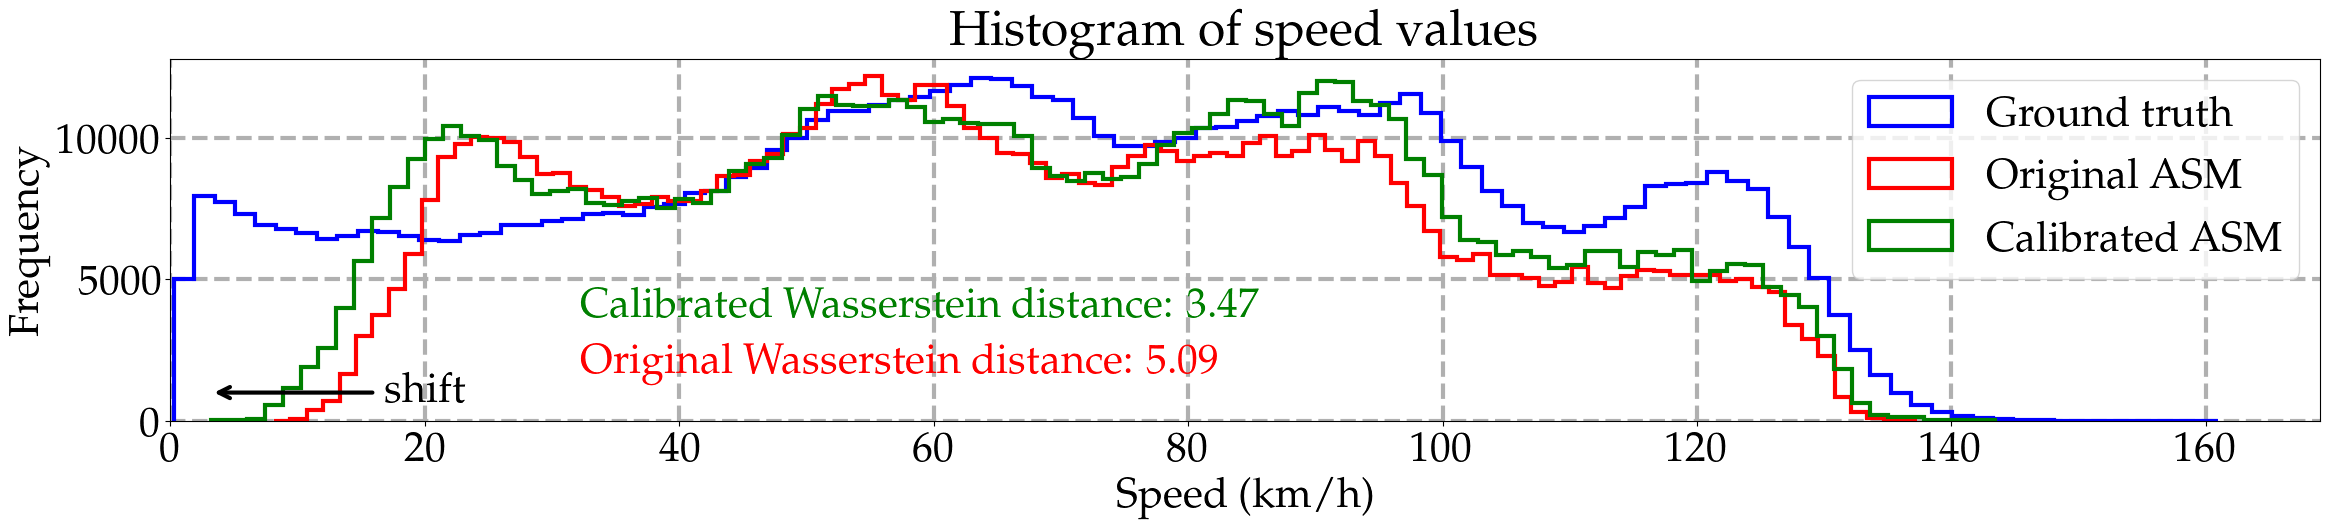

In [7]:
plt.figure(figsize=(24, 6))
plt.rcParams.update({'font.size': 30, 'font.family': 'serif'})
plt.hist(MILE_TO_KM * motion.flatten(), bins=100, histtype='step', color='blue', label='Ground truth', linewidth=3)
plt.hist(MILE_TO_KM * original_asm_speed.flatten(), bins=100, histtype='step', color='red', label='Original ASM', linewidth=3)
plt.hist(MILE_TO_KM * calibrated_asm_speed.flatten(), bins=100, histtype='step', color='green', label='Calibrated ASM', linewidth=3)
plt.xlabel('Speed (km/h)')
plt.ylabel('Frequency')
plt.title('Histogram of speed values')
plt.legend()
plt.tight_layout()
plt.xlim(0, )
plt.grid(lw=3, ls='--')
# add an arrow at (10, 1000) pointing to the right
plt.annotate('', xy=(MILE_TO_KM * 2, 1000), xytext=(MILE_TO_KM * 10, 1000),
             arrowprops=dict(arrowstyle='->', lw=3, color='black'),
             fontsize=20, ha='center', va='center')
# add text at the arrow
plt.text(MILE_TO_KM * 10.5, 1000, 'shift', fontsize=30, ha='left', va='center', color='black')
# calculate the Wesserstain distance
from scipy.stats import wasserstein_distance
wd = wasserstein_distance(MILE_TO_KM * motion.flatten(), MILE_TO_KM * calibrated_asm_speed.flatten())
rmse = np.sqrt(np.mean((MILE_TO_KM * motion.flatten() - MILE_TO_KM * calibrated_asm_speed.flatten())**2))
print(f'Calibrated Wasserstein distance: {wd:.2f}')
print(f'Calibrated RMSE: {rmse:.2f}')
plt.text(MILE_TO_KM * 20, 4000, f'Calibrated Wasserstein distance: {wd:.2f}', fontsize=30, ha='left', va='center', color='green')
wd = wasserstein_distance(MILE_TO_KM * motion.flatten(), MILE_TO_KM * original_asm_speed.flatten())
rmse = np.sqrt(np.mean((MILE_TO_KM * motion.flatten() - MILE_TO_KM * original_asm_speed.flatten())**2))
print(f'Original Wasserstein distance: {wd:.2f}')
print(f'Original RMSE: {rmse:.2f}')
plt.text(MILE_TO_KM * 20, 2000, f'Original Wasserstein distance: {wd:.2f}', fontsize=30, ha='left', va='center', color='red')
if not os.path.exists('../figures/figure6'):
    os.makedirs('../figures/figure6')
plt.savefig('../figures/figure6/histogram.pdf', dpi=300, bbox_inches='tight')
plt.show()

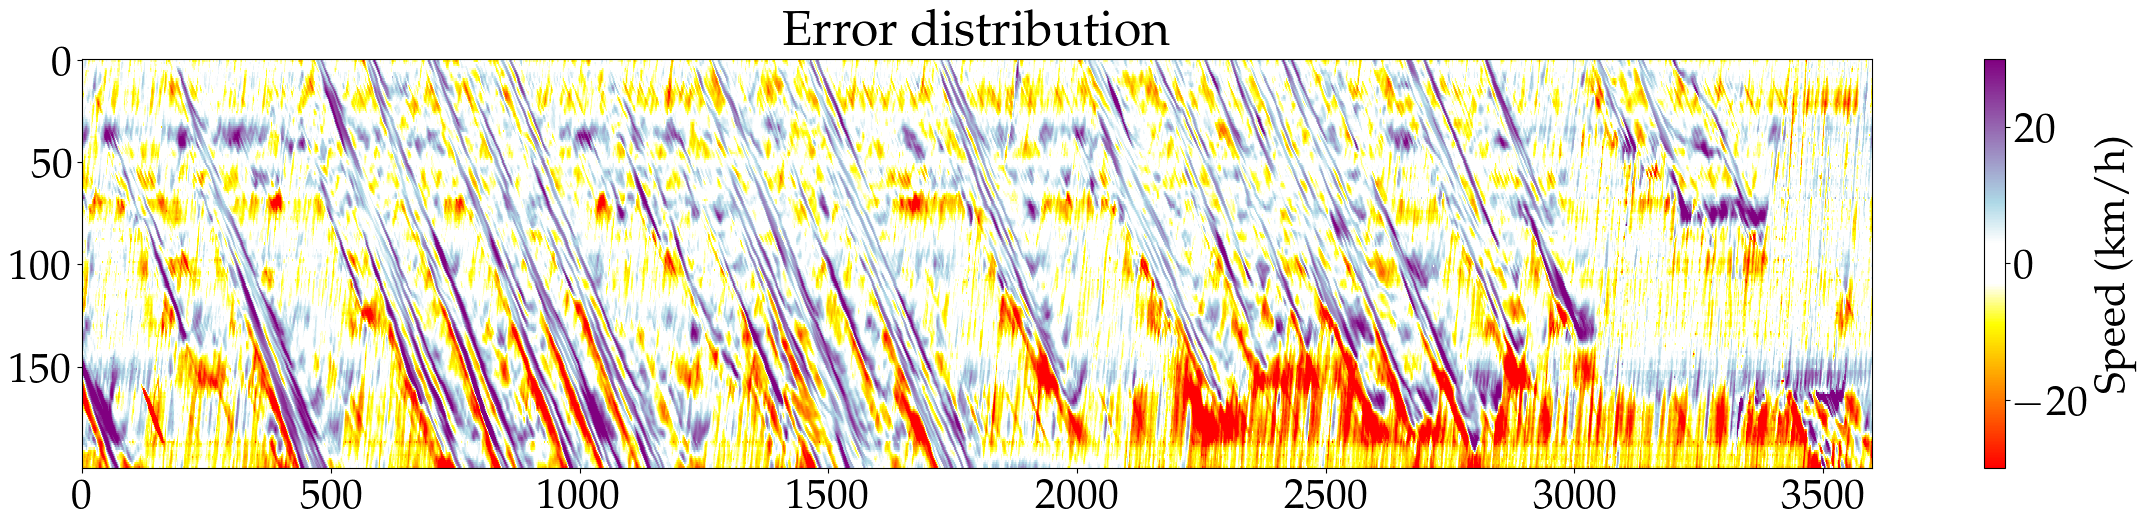

In [8]:
plt.figure(figsize=(24, 6))
plt.rcParams.update({'font.size': 30, 'font.family': 'serif'})
colors = ['red','yellow','white', 'white', 'white','lightblue','purple']
nodes = [0, 0.35,0.45,0.5,0.55,0.65, 1]  # Normalized nodes
cmap = LinearSegmentedColormap.from_list('custom', list(zip(nodes, colors)))
plt.imshow(MILE_TO_KM * calibrated_asm_speed - MILE_TO_KM * motion, cmap=cmap, interpolation='nearest', origin='lower',
           vmin=-30, vmax=30, aspect='auto')
plt.colorbar(label='Speed (km/h)')
plt.title('Error distribution')
plt.tight_layout()
# reverse y-axis to match the original plot
plt.gca().invert_yaxis()
import os
if not os.path.exists('../figures/figure7'):
    os.makedirs('../figures/figure7')
plt.savefig('../figures/figure7/error.pdf', dpi=300, bbox_inches='tight')
plt.show()

RDS Index: [  5   5   5 ... 196 196 196]


RDS Index: [  5   5   5 ... 196 196 196]


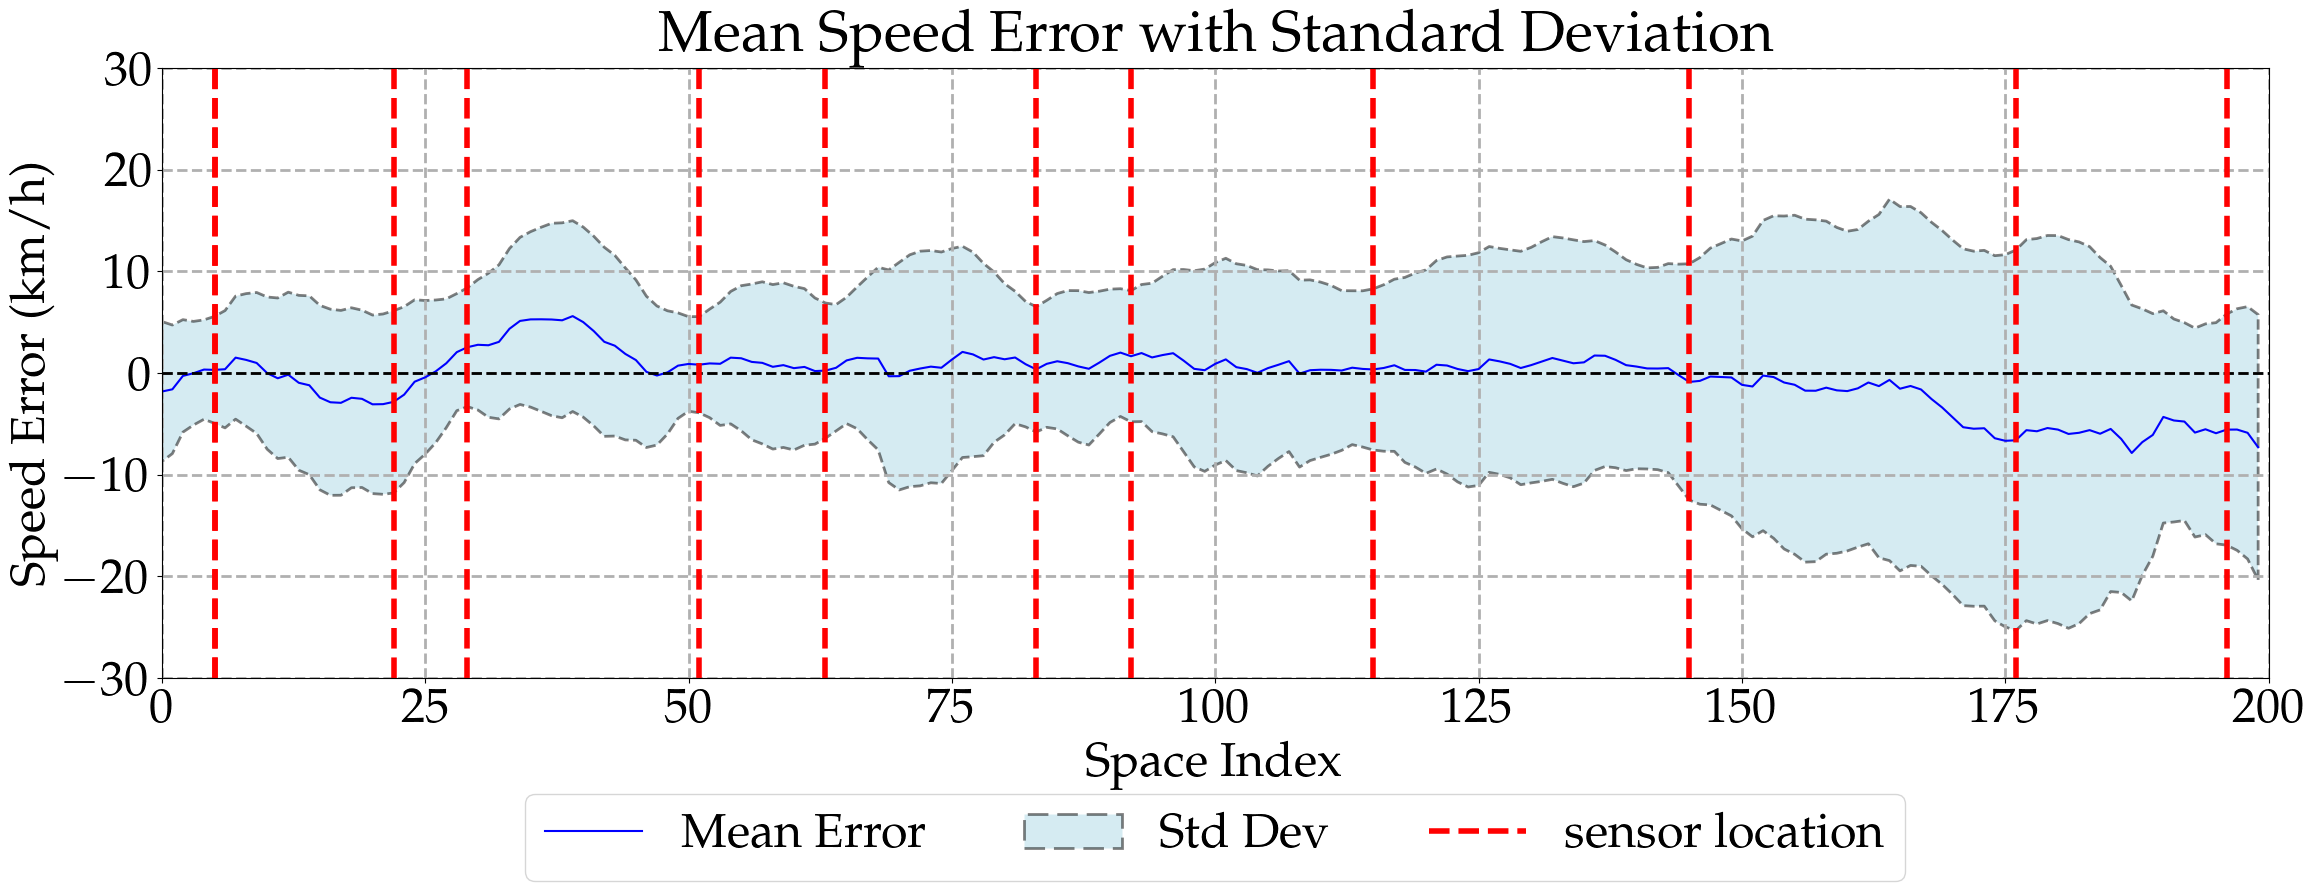

In [9]:
# show the error distribution along th y-axis
plt.figure(figsize=(24, 10))
plt.rcParams.update({'font.size': 35, 'font.family': 'serif'})
error = MILE_TO_KM * calibrated_asm_speed - MILE_TO_KM * motion
# get the index of rds not all the element are nan
rds_index = np.where(~np.isnan(rds))[0]
print(f"RDS Index: {rds_index}")
# get the unique index
unique_rds_index = np.unique(rds_index)
plt.plot(np.mean(error, axis=1), label='Mean Error', color='blue')
# error2 = original_asm_speed - motion
# plt.fill_between(
#     range(error2.shape[0]),
#     np.mean(error2, axis=1) - np.std(error2, axis=1),
#     np.mean(error2, axis=1) + np.std(error2, axis=1),
#     color='orange', alpha = 0.2, label='Original Std Dev',
#     edgecolor='black', linewidth=1, linestyle='--'
# )
plt.fill_between(
    range(error.shape[0]),
    np.mean(error, axis=1) - np.std(error, axis=1),
    np.mean(error, axis=1) + np.std(error, axis=1),
    color='lightblue', alpha=0.5, label='Std Dev',
    edgecolor='black', linewidth=2, linestyle='--'
)
plt.axhline(0, color='black', linestyle='--', linewidth=2)
plt.xlabel('Space Index')
plt.ylabel('Speed Error (km/h)')
plt.title('Mean Speed Error with Standard Deviation')
# draw vertical lines at the rds index
for idx in unique_rds_index:
    plt.axvline(x=idx, color='red', linestyle='--', linewidth=4, label = 'sensor location')
    break
for idx in unique_rds_index:
    plt.axvline(x=idx, color='red', linestyle='--', linewidth=4)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, fontsize=35)
plt.xlim(0, error.shape[0])
plt.ylim(-30, 30)
plt.grid(lw=2, ls='--')
plt.tight_layout()
if not os.path.exists('../figures/figure8'):
    os.makedirs('../figures/figure8')
plt.savefig('../figures/figure8/mean_error_location.pdf', dpi=300, bbox_inches='tight')
plt.show()

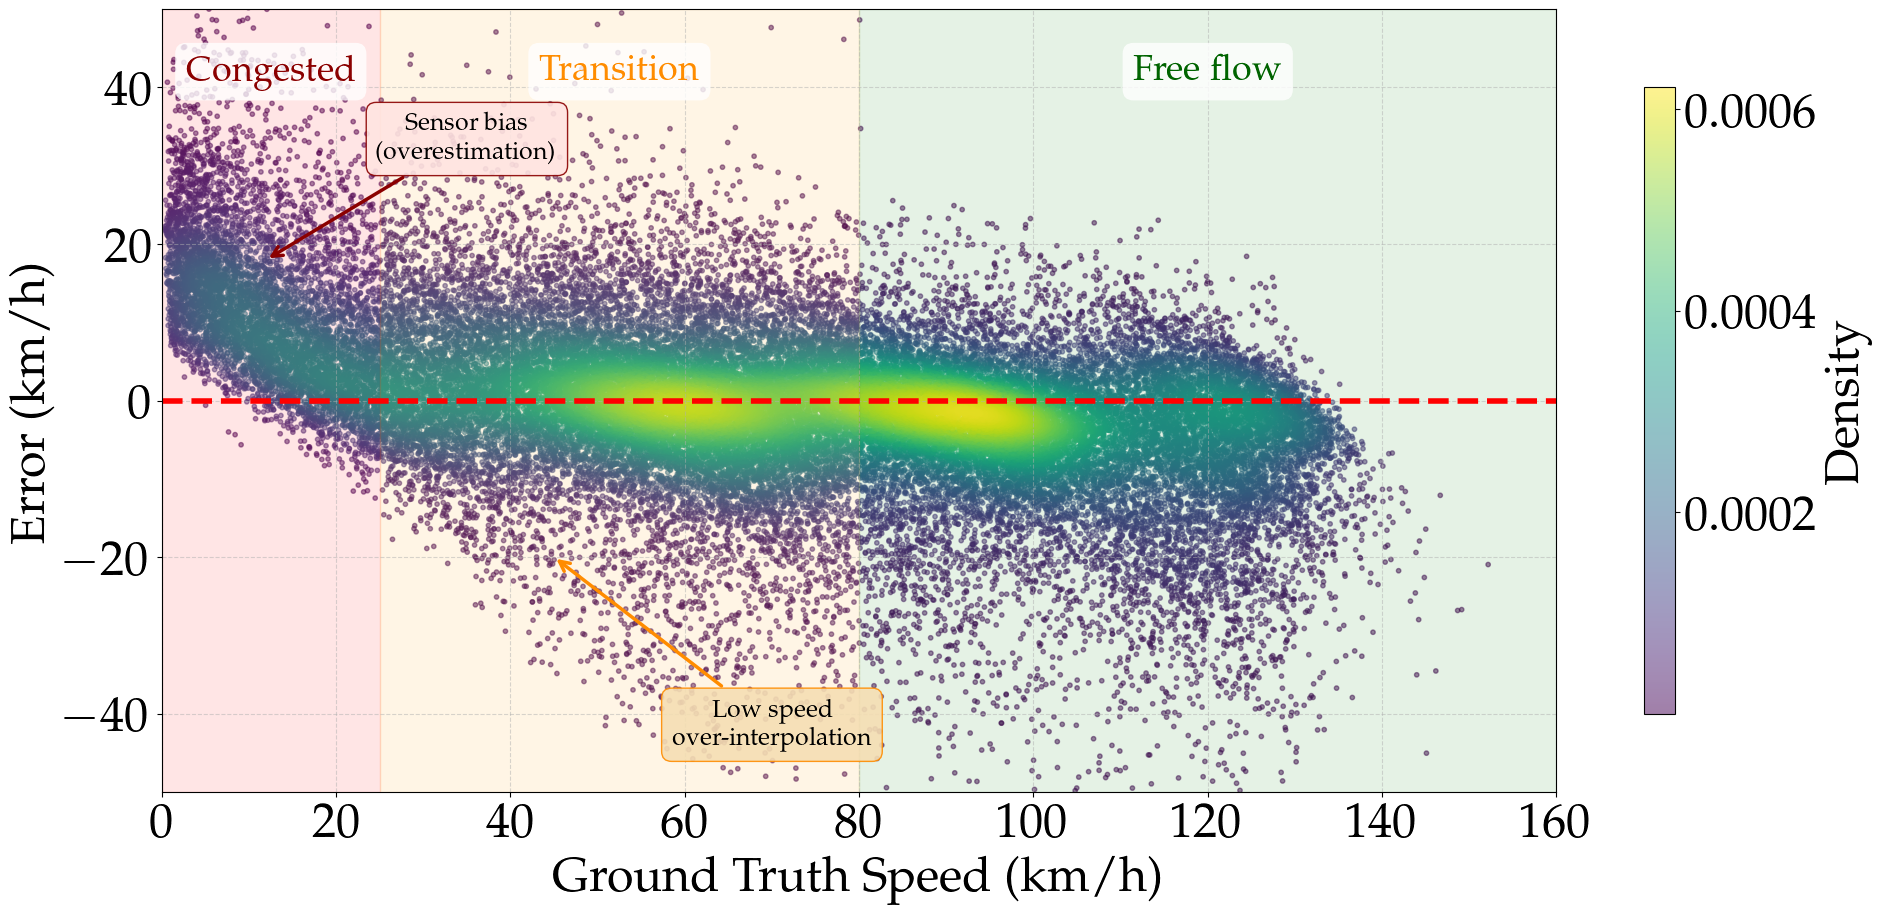

In [32]:
from scipy.stats import gaussian_kde

plt.figure(figsize=(20, 10))
plt.rcParams.update({'font.size': 35})

# Flatten data
x_data = MILE_TO_KM * motion.flatten()
y_data = (MILE_TO_KM * calibrated_asm_speed - MILE_TO_KM * motion).flatten()

# Calculate KDE for point density coloring
# Subsample for KDE calculation (full dataset too large)
sample_size = min(50000, len(x_data))
idx = np.random.choice(len(x_data), sample_size, replace=False)
x_sample, y_sample = x_data[idx], y_data[idx]

# Calculate point density using KDE
xy = np.vstack([x_sample, y_sample])
kde = gaussian_kde(xy)
density = kde(xy)

# Sort by density so highest density points are plotted on top
sorted_idx = np.argsort(density)
x_sorted = x_sample[sorted_idx]
y_sorted = y_sample[sorted_idx]
density_sorted = density[sorted_idx]

# Create scatter plot with density coloring
scatter = plt.scatter(x_sorted, y_sorted, c=density_sorted, cmap='viridis', 
                      alpha=0.5, s=10, rasterized=True)
cbar = plt.colorbar(scatter, label='Density', shrink=0.8)

plt.axhline(0, color='red', linestyle='--', linewidth=4)

# Add shaded regions for different traffic regimes
ax = plt.gca()

# Congested region (0-25 km/h)
ax.axvspan(0, 25, alpha=0.1, color='red', label='Congested')
# Transition/Shockwave region (25-80 km/h) 
ax.axvspan(25, 80, alpha=0.1, color='orange', label='Transition')
# Free flow region (>80 km/h)
ax.axvspan(80, 170, alpha=0.1, color='green', label='Free flow')

# Add text annotations with white background for clarity
bbox_props = dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='none', alpha=0.8)

plt.text(12.5, 42, 'Congested', fontsize=26, ha='center', va='center', 
         color='darkred', fontweight='bold', bbox=bbox_props)
plt.text(52.5, 42, 'Transition', fontsize=26, ha='center', va='center', 
         color='darkorange', fontweight='bold', bbox=bbox_props)
plt.text(120, 42, 'Free flow', fontsize=26, ha='center', va='center', 
         color='darkgreen', fontweight='bold', bbox=bbox_props)

# Add arrows indicating error characteristics with clear labels
plt.annotate('Low speed\nover-interpolation', xy=(45, -20), xytext=(70, -38),
             fontsize=18, ha='center', va='top', color='black', fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.4', facecolor='wheat', edgecolor='darkorange', alpha=0.9),
             arrowprops=dict(arrowstyle='->', lw=2.5, color='darkorange'))

plt.annotate('Sensor bias\n(overestimation)', xy=(12, 18), xytext=(35, 30),
             fontsize=18, ha='center', va='bottom', color='black', fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.4', facecolor='mistyrose', edgecolor='darkred', alpha=0.9),
             arrowprops=dict(arrowstyle='->', lw=2.5, color='darkred'))

plt.xlabel('Ground Truth Speed (km/h)')
plt.ylabel('Error (km/h)')
plt.grid(True, ls='--', alpha=0.5)
plt.xlim(0, 160)
plt.ylim(-50, 50)
plt.tight_layout()

if not os.path.exists('../figures/figure7'):
    os.makedirs('../figures/figure7')
plt.savefig('../figures/figure7/residuals.pdf', dpi=300, bbox_inches='tight')
plt.show()